<a href="https://colab.research.google.com/github/CipherSunaina02/Flyrank-ml-internship/blob/main/work/notebooks/capstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/CipherSunaina02/Flyrank-ml-internship/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

*The research question and the decision it supports.*
### Research question

Can February 2026 content-performance signals be used to identify and rank content that may need review for possible decline in March 2026?

The decision supported by this analysis is:

**Which content should a human SEO or content reviewer inspect first?**

The model is used as a directional decision-support tool for prioritization. It is not intended to guarantee future decline or predict Google's ranking algorithm.

In [ ]:
print("CAPSTONE — RESEARCH QUESTION")
print()
print("Question:")
print(
    "Can February 2026 content-performance signals be used "
    "to identify and rank content that may need review "
    "for possible decline in March 2026?"
)

print()
print("Decision supported:")
print(
    "Which content should a human SEO or content reviewer "
    "inspect first?"
)

print()
print("Intended use: directional decision support")
print("Automatic SEO action: NO")
print("Causal claim: NO")

CAPSTONE — RESEARCH QUESTION

Question:
Can February 2026 content-performance signals be used to identify and rank content that may need review for possible decline in March 2026?

Decision supported:
Which content should a human SEO or content reviewer inspect first?

Intended use: directional decision support
Automatic SEO action: NO
Causal claim: NO


## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

### Data source and study windows

This study uses the FlyRank internship warehouse release available through the Hugging Face warehouse.

The main table is `fact_content_daily_performance`, with daily observations at the client × content × day grain.

The analysis uses:
- **Feature window:** February 2026
- **Outcome window:** March 2026

February data are used to construct model features. March clicks are used only to define the outcome label and are not included as model features.

Rows were aggregated to the client × content level before modeling. Content keys without a measurable March outcome were excluded because the decline label could not be defined reliably for them. Missing feature values were handled as zero after aggregation for the modeling matrix.

The public analysis uses hashed content/client identifiers and aggregate performance fields. Client names, domains, URLs, private queries, credentials, and raw private exports are not included in the paper outputs.

In [ ]:
print("CAPSTONE — DATA AUDIT")

import os
import numpy as np
import pandas as pd

# Set up DuckDB/Hugging Face access if this is a fresh runtime
if "con" not in globals():
    %pip install -q duckdb huggingface_hub pandas scikit-learn matplotlib

    import duckdb
    from google.colab import userdata

    HF_TOKEN = userdata.get("HF_TOKEN")

    if not HF_TOKEN:
        raise ValueError("HF_TOKEN is not available in Colab Secrets.")

    con = duckdb.connect()

    con.execute("SET VARIABLE hf_token = ?", [HF_TOKEN])

    con.execute("""
        CREATE OR REPLACE SECRET hf_secret (
            TYPE HUGGINGFACE,
            TOKEN getvariable('hf_token')
        )
    """)

FACT = "hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance"

FEB = f"{FACT}/month=2026-02/*.parquet"
MAR = f"{FACT}/month=2026-03/*.parquet"

# February feature-window audit
feb_audit = con.sql(f"""
    SELECT
        COUNT(*) AS feb_daily_rows,
        COUNT(DISTINCT client_hash_id) AS feb_clients,
        COUNT(DISTINCT content_hash_id) AS feb_contents,
        MIN(report_date) AS feb_start,
        MAX(report_date) AS feb_end
    FROM read_parquet('{FEB}')
""").df()

# March outcome-window audit
mar_audit = con.sql(f"""
    SELECT
        COUNT(*) AS mar_daily_rows,
        COUNT(DISTINCT client_hash_id) AS mar_clients,
        COUNT(DISTINCT content_hash_id) AS mar_contents,
        MIN(report_date) AS mar_start,
        MAX(report_date) AS mar_end
    FROM read_parquet('{MAR}')
""").df()

print("\nFebruary 2026 feature window:")
display(feb_audit)

print("\nMarch 2026 outcome window:")
display(mar_audit)

# Reproduce the modeling-level join counts
feb_keys = con.sql(f"""
    SELECT
        client_hash_id,
        content_hash_id,
        SUM(gsc_impressions) AS feb_impressions,
        SUM(gsc_clicks) AS feb_clicks,
        AVG(gsc_avg_position) AS feb_avg_position
    FROM read_parquet('{FEB}')
    GROUP BY client_hash_id, content_hash_id
""").df()

mar_keys = con.sql(f"""
    SELECT
        client_hash_id,
        content_hash_id,
        SUM(gsc_clicks) AS mar_clicks
    FROM read_parquet('{MAR}')
    GROUP BY client_hash_id, content_hash_id
""").df()

data_join = feb_keys.merge(
    mar_keys,
    on=["client_hash_id", "content_hash_id"],
    how="inner"
)

data_join = data_join.dropna(subset=["mar_clicks"]).copy()

data_join["decline_label"] = (
    data_join["mar_clicks"] < data_join["feb_clicks"]
).astype(int)

print("\nModeling population:")
print("Joined client-content rows:", len(data_join))
print("Clients:", data_join["client_hash_id"].nunique())
print("Content IDs:", data_join["content_hash_id"].nunique())
print("Decline labels:", int(data_join["decline_label"].sum()))
print("Non-decline labels:", int((data_join["decline_label"] == 0).sum()))

print("\nExclusion rule:")
print("Content keys without a measurable March outcome: EXCLUDED")
print("March outcome variables used as model features: NO")
print("Private identifiers/URLs exported: NO")
print("Data audit: PASSED")

CAPSTONE — DATA AUDIT

February 2026 feature window:


,feb_daily_rows,feb_clients,feb_contents,feb_start,feb_end
0,7355108,54,321546,2026-02-01,2026-02-28



March 2026 outcome window:


,mar_daily_rows,mar_clients,mar_contents,mar_start,mar_end
0,9841378,55,331437,2026-03-01,2026-03-31



Modeling population:
Joined client-content rows: 303572
Clients: 50
Content IDs: 303572
Decline labels: 24829
Non-decline labels: 278743

Exclusion rule:
Content keys without a measurable March outcome: EXCLUDED
March outcome variables used as model features: NO
Private identifiers/URLs exported: NO
Data audit: PASSED


## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

### Methodology

The analysis uses February 2026 content-performance measurements as model features and March 2026 clicks only to define the outcome.

The model features are:

- February impressions
- February clicks
- February average position
- February pageviews
- February sessions
- February users
- February engaged sessions
- February total engagement seconds
- February organic sessions
- February AI sessions

The decline label is defined as:

**decline = 1 when March clicks are lower than February clicks; otherwise 0.**

A simple baseline predicts the majority class in the evaluation set. The model is Logistic Regression with standardized features.

The main validation uses a client-grouped 80/20 split so that clients in the test set do not appear in the training set. This is more conservative than a random row split because content from the same client can share client-specific patterns.

Leakage checks exclude March outcome variables, label-derived fields, future information, and decision-derived product flags from the feature vector. A deliberate March-click leakage test is also used to verify that the leakage harness can detect an obviously future-derived feature.

The resulting score is treated as a ranking and prioritization signal rather than a calibrated probability or guaranteed prediction.

In [ ]:
print("CAPSTONE — METHODOLOGY AUDIT")

import numpy as np
import pandas as pd

from sklearn.model_selection import GroupShuffleSplit
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

# February-only model features
feature_cols = [
    "feb_impressions",
    "feb_clicks",
    "feb_avg_position",
    "feb_pageviews",
    "feb_sessions",
    "feb_users",
    "feb_engaged_sessions",
    "feb_engagement_sec",
    "feb_organic_sessions",
    "feb_ai_sessions"
]

# Rebuild the full February feature matrix
feb_features = con.sql(f"""
    SELECT
        client_hash_id,
        content_hash_id,
        SUM(gsc_impressions) AS feb_impressions,
        SUM(gsc_clicks) AS feb_clicks,
        AVG(gsc_avg_position) AS feb_avg_position,
        SUM(ga4_pageviews) AS feb_pageviews,
        SUM(ga4_sessions) AS feb_sessions,
        SUM(ga4_users) AS feb_users,
        SUM(ga4_engaged_sessions) AS feb_engaged_sessions,
        SUM(ga4_total_engagement_sec) AS feb_engagement_sec,
        SUM(sessions_organic) AS feb_organic_sessions,
        SUM(sessions_ai) AS feb_ai_sessions
    FROM read_parquet('{FEB}')
    GROUP BY client_hash_id, content_hash_id
""").df()

# March is used only to construct the outcome
march_outcome = con.sql(f"""
    SELECT
        client_hash_id,
        content_hash_id,
        SUM(gsc_clicks) AS mar_clicks
    FROM read_parquet('{MAR}')
    GROUP BY client_hash_id, content_hash_id
""").df()

model_df = feb_features.merge(
    march_outcome,
    on=["client_hash_id", "content_hash_id"],
    how="inner"
).dropna(subset=["mar_clicks"]).copy()

model_df["decline_label"] = (
    model_df["mar_clicks"] < model_df["feb_clicks"]
).astype(int)

X = (
    model_df[feature_cols]
    .replace([np.inf, -np.inf], np.nan)
    .fillna(0)
)

y = model_df["decline_label"]
groups = model_df["client_hash_id"]

# Honest client-grouped 80/20 split
gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_idx, test_idx = next(
    gss.split(X, y, groups=groups)
)

X_train = X.iloc[train_idx]
X_test = X.iloc[test_idx]
y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]

train_clients = set(model_df.iloc[train_idx]["client_hash_id"])
test_clients = set(model_df.iloc[test_idx]["client_hash_id"])

# Logistic Regression model
capstone_model = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

capstone_model.fit(X_train, y_train)

model_pred = capstone_model.predict(X_test)
model_accuracy = accuracy_score(y_test, model_pred)

# Majority-class baseline
majority_class = y_train.mode()[0]
baseline_pred = np.full(len(y_test), majority_class)
baseline_accuracy = accuracy_score(y_test, baseline_pred)

print("\nValidation design")
print("Split type: CLIENT-GROUPED")
print("Train rows:", len(X_train))
print("Test rows:", len(X_test))
print("Training clients:", len(train_clients))
print("Testing clients:", len(test_clients))
print("Client overlap:", len(train_clients & test_clients))

print("\nModel")
print("Algorithm: Logistic Regression")
print("Feature count:", len(feature_cols))
print("Future March features included: NO")

print("\nResults")
print("Grouped model accuracy:", round(model_accuracy, 4))
print("Grouped baseline accuracy:", round(baseline_accuracy, 4))
print("Test-set decline base rate:", round(y_test.mean(), 4))

print("\nLeakage checks")
future_feature_names = [
    "mar_clicks",
    "trend_direction",
    "trend_pct",
    "decline_label"
]

used_future_features = [
    f for f in future_feature_names
    if f in feature_cols
]

print("Future/label-derived features in final vector:", used_future_features)
print("Direct leakage check:", "PASSED" if len(used_future_features) == 0 else "FAILED")

# Deliberate leakage test
leaky_X = X.copy()
leaky_X["LEAKY_MARCH_CLICKS"] = model_df["mar_clicks"].values

leaky_train = leaky_X.iloc[train_idx]
leaky_test = leaky_X.iloc[test_idx]

leaky_model = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

leaky_model.fit(leaky_train, y_train)
leaky_accuracy = accuracy_score(
    y_test,
    leaky_model.predict(leaky_test)
)

print("Deliberate March-click leakage accuracy:", round(leaky_accuracy, 4))
print("Deliberate leakage feature included in final model: NO")

print("\nMethodology audit: PASSED")

assert len(train_clients & test_clients) == 0
assert len(used_future_features) == 0

CAPSTONE — METHODOLOGY AUDIT


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))


Validation design
Split type: CLIENT-GROUPED
Train rows: 264134
Test rows: 39438
Training clients: 40
Testing clients: 10
Client overlap: 0

Model
Algorithm: Logistic Regression
Feature count: 10
Future March features included: NO

Results
Grouped model accuracy: 0.8782
Grouped baseline accuracy: 0.8794
Test-set decline base rate: 0.1206

Leakage checks
Future/label-derived features in final vector: []
Direct leakage check: PASSED
Deliberate March-click leakage accuracy: 0.9998
Deliberate leakage feature included in final model: NO

Methodology audit: PASSED


## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*
### Results

The model and baseline are evaluated on the same client-grouped test split.

| Method | Validation design | Accuracy | Decline base rate |
|---|---|---:|---:|
| Majority-class baseline | Client-grouped 80/20 | 0.8794 | 0.1206 |
| Logistic Regression | Client-grouped 80/20 | 0.8782 | 0.1206 |

Under the honest client-grouped validation, Logistic Regression does not outperform the majority-class baseline. The earlier row-split result of 0.9627 accuracy was higher, but the client-grouped result is more conservative and indicates that the row-split estimate was optimistic.

The model is therefore retained as a directional ranking and prioritization experiment rather than as a demonstrated improvement over the baseline.

In [ ]:
print("CAPSTONE — RESULTS VS BASELINE")

results_table = pd.DataFrame({
    "Method": [
        "Majority-class baseline",
        "Logistic Regression"
    ],
    "Validation": [
        "Client-grouped 80/20",
        "Client-grouped 80/20"
    ],
    "Accuracy": [
        round(baseline_accuracy, 4),
        round(model_accuracy, 4)
    ],
    "Decline base rate": [
        round(float(y_test.mean()), 4),
        round(float(y_test.mean()), 4)
    ]
})

display(results_table)

accuracy_gap = model_accuracy - baseline_accuracy

print("\nAccuracy gap (model - baseline):",
      round(accuracy_gap, 4))

print("\nEarlier row-split model accuracy: 0.9627")
print("Honest grouped model accuracy:",
      round(model_accuracy, 4))

if model_accuracy > baseline_accuracy:
    print("Model beats grouped baseline: YES")
else:
    print("Model beats grouped baseline: NO")

print("\nInterpretation:")
print(
    "The client-grouped result is the primary result because "
    "the test clients were not present during training."
)

print("\nResults table: PASSED")

CAPSTONE — RESULTS VS BASELINE


,Method,Validation,Accuracy,Decline base rate
0,Majority-class baseline,Client-grouped 80/20,0.8794,0.1206
1,Logistic Regression,Client-grouped 80/20,0.8782,0.1206



Accuracy gap (model - baseline): -0.0012

Earlier row-split model accuracy: 0.9627
Honest grouped model accuracy: 0.8782
Model beats grouped baseline: NO

Interpretation:
The client-grouped result is the primary result because the test clients were not present during training.

Results table: PASSED


## 5. Limitations

*What this work cannot claim.*
### Limitations

This study has several limitations.

First, the March decline label is defined from a simple comparison of March clicks with February clicks. It is an outcome definition for this study, not a universal definition of content decline.

Second, the client-grouped validation result shows that the Logistic Regression model did not outperform the majority-class baseline. The earlier row-split result was higher, indicating that a random row split can give an optimistic estimate when content from the same client appears in both training and testing data.

Third, the analysis is observational. It cannot establish that content age, word count, engagement, freshness, or any other measured signal causes search-performance changes. It also cannot establish that refreshing a page will improve its future performance.

Fourth, the model uses a limited set of February performance features and only one February-to-March outcome window. Results may not generalize to different time periods, clients, topics, or data conditions.

Finally, the action queue should be treated as a prioritization experiment for human review. It is not a system for predicting Google's ranking algorithm or automatically deciding which pages should be changed, deleted, redirected, or republished.

In [ ]:
print("CAPSTONE — LIMITATIONS CHECK")

limitations = [
    "Study-specific decline label",
    "Grouped model does not beat majority baseline",
    "Row-split result may be optimistic",
    "Observational data cannot establish causation",
    "Single feature/outcome window limits generalization",
    "Limited February feature set",
    "Action queue requires human review",
    "Not a prediction of Google's ranking algorithm"
]

for i, item in enumerate(limitations, 1):
    print(f"{i}. {item}")

print("\nPrimary grouped model accuracy:", round(model_accuracy, 4))
print("Primary grouped baseline accuracy:", round(baseline_accuracy, 4))
print("Model improvement over baseline:", round(model_accuracy - baseline_accuracy, 4))
print("Causal claim supported: NO")
print("Automatic action supported: NO")
print("Limitations check: PASSED")

CAPSTONE — LIMITATIONS CHECK
1. Study-specific decline label
2. Grouped model does not beat majority baseline
3. Row-split result may be optimistic
4. Observational data cannot establish causation
5. Single feature/outcome window limits generalization
6. Limited February feature set
7. Action queue requires human review
8. Not a prediction of Google's ranking algorithm

Primary grouped model accuracy: 0.8782
Primary grouped baseline accuracy: 0.8794
Model improvement over baseline: -0.0012
Causal claim supported: NO
Automatic action supported: NO
Limitations check: PASSED


## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

### Ranked recommendations

The action playbook ranks content using the Logistic Regression decline score from the client-grouped validation design.

The ranking is intended to help a human reviewer decide which content to inspect first. Each item also receives a reason code and action label based on February performance context.

The main recommendation categories are:

1. **LOW_VISIBILITY_REFRESH** — review content with weak search visibility.
2. **VISIBLE_LOW_ENGAGEMENT** — review visible content with weak measured engagement.
3. **PROTECT_EXISTING_VISIBILITY** — review pages that already have search visibility before making substantial changes.
4. **LOW_DATA_REVIEW** — verify data availability before taking action.

These are workflow cues, not automatic instructions. A reviewer should consider search intent, content quality, freshness, business importance, and data quality before acting.

Because the grouped model did not outperform the majority-class baseline, the ranked queue should be treated as an exploratory prioritization output rather than a demonstrated predictive advantage.

In [ ]:
print("CAPSTONE — RANKED RECOMMENDATIONS")

import os
import numpy as np
import pandas as pd

# Recreate the recommendation scores on the unseen-client test set
recommendation_df = model_df.iloc[test_idx].copy()

recommendation_df["decline_risk_score"] = (
    capstone_model.predict_proba(X_test)[:, 1]
)

# Reason codes based only on February information
def assign_reason(row):
    position = row["feb_avg_position"]
    impressions = row["feb_impressions"]
    engagement = row["feb_engagement_sec"]

    if position > 20 and impressions > 0:
        return "LOW_VISIBILITY_REFRESH"

    if position <= 20 and impressions > 0 and engagement <= 0:
        return "VISIBLE_LOW_ENGAGEMENT"

    if position <= 20 and impressions > 0:
        return "PROTECT_EXISTING_VISIBILITY"

    if impressions <= 0:
        return "LOW_DATA_REVIEW"

    return "GENERAL_REFRESH_REVIEW"


recommendation_df["reason_code"] = recommendation_df.apply(
    assign_reason,
    axis=1
)

# Action labels
def assign_action(reason):
    if reason == "LOW_VISIBILITY_REFRESH":
        return "REVIEW_CONTENT_REFRESH"

    if reason == "VISIBLE_LOW_ENGAGEMENT":
        return "REVIEW_ENGAGEMENT"

    if reason == "PROTECT_EXISTING_VISIBILITY":
        return "REVIEW_PAGE_ONE"

    if reason == "LOW_DATA_REVIEW":
        return "VERIFY_DATA"

    return "REVIEW_CONTENT"


recommendation_df["action_label"] = (
    recommendation_df["reason_code"].map(assign_action)
)

# Rank by model score
recommendations = (
    recommendation_df[
        [
            "content_hash_id",
            "decline_risk_score",
            "reason_code",
            "action_label",
            "feb_impressions",
            "feb_clicks",
            "feb_avg_position",
            "feb_engagement_sec"
        ]
    ]
    .sort_values(
        "decline_risk_score",
        ascending=False
    )
    .reset_index(drop=True)
)

recommendations.insert(
    0,
    "rank",
    np.arange(1, len(recommendations) + 1)
)

print("\nTop 20 review candidates:")
display(recommendations.head(20))

print("\nRecommendation distribution:")
display(
    recommendations["reason_code"]
    .value_counts()
    .rename_axis("reason_code")
    .reset_index(name="count")
)

# Save capstone-ready top 20
os.makedirs("work/outputs", exist_ok=True)

top20_path = (
    "work/outputs/"
    "capstone_top20_recommendations.csv"
)

recommendations.head(20).to_csv(
    top20_path,
    index=False
)

print("\nSaved:", top20_path)

print("\nRecommendation safeguards")
print("Rank based on model score: YES")
print("Reason codes included: YES")
print("Client names/domains/URLs included: NO")
print("Automatic action: NO")
print("Human review required: YES")
print("Ranked recommendations: PASSED")

CAPSTONE — RANKED RECOMMENDATIONS

Top 20 review candidates:


,rank,content_hash_id,decline_risk_score,reason_code,action_label,feb_impressions,feb_clicks,feb_avg_position,feb_engagement_sec
0,1,content_eadb33b5df496f4a,1.000000,PROTECT_EXISTING_VISIBILITY,REVIEW_PAGE_ONE,94852.0,1123.0,2.559384,8048.0
1,2,content_c9a0c2fdbdbfb562,1.000000,PROTECT_EXISTING_VISIBILITY,REVIEW_PAGE_ONE,142215.0,1605.0,1.882000,4292.0
2,3,content_ec2e0346994fb5a5,1.000000,PROTECT_EXISTING_VISIBILITY,REVIEW_PAGE_ONE,119854.0,490.0,2.594817,12219.0
3,4,content_7de2236ec61ba4c5,1.000000,PROTECT_EXISTING_VISIBILITY,REVIEW_PAGE_ONE,58591.0,590.0,4.838177,3082.0
4,5,content_21309e9a83c83653,1.000000,PROTECT_EXISTING_VISIBILITY,REVIEW_PAGE_ONE,106013.0,229.0,4.422467,821.0
5,6,content_425a23ff83f9f448,1.000000,PROTECT_EXISTING_VISIBILITY,REVIEW_PAGE_ONE,40086.0,452.0,5.241112,7154.0
6,7,content_a6b170f18f827a7f,1.000000,PROTECT_EXISTING_VISIBILITY,REVIEW_PAGE_ONE,24105.0,431.0,4.143416,2634.0
7,8,content_6b4ba5a247ea6100,1.000000,PROTECT_EXISTING_VISIBILITY,REVIEW_PAGE_ONE,57917.0,424.0,3.986528,NaN
8,9,content_86c036a549cbbfd5,1.000000,PROTECT_EXISTING_VISIBILITY,REVIEW_PAGE_ONE,40374.0,412.0,2.717006,9639.0
9,10,content_3508adb0f05ec0b9,0.999999,PROTECT_EXISTING_VISIBILITY,REVIEW_PAGE_ONE,44487.0,291.0,3.452090,4187.0



Recommendation distribution:


,reason_code,count
0,LOW_DATA_REVIEW,16162
1,VISIBLE_LOW_ENGAGEMENT,9631
2,PROTECT_EXISTING_VISIBILITY,9078
3,LOW_VISIBILITY_REFRESH,4567



Saved: work/outputs/capstone_top20_recommendations.csv

Recommendation safeguards
Rank based on model score: YES
Reason codes included: YES
Client names/domains/URLs included: NO
Automatic action: NO
Human review required: YES
Ranked recommendations: PASSED


## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

### Paper-ready artifacts

The capstone exports reproducible tables and figures for the deployed research paper.

The main artifacts summarize:
- model performance versus the majority-class baseline on the same client-grouped test split;
- the distribution of recommendation reason codes;
- the highest-ranked content review candidates.

The figures are descriptive and decision-support artifacts. They do not imply that the model causes content decline or that a recommended refresh will improve performance.

CAPSTONE — PAPER ARTIFACTS

Results table:


,method,validation,accuracy,decline_base_rate
0,Majority-class baseline,Client-grouped 80/20,0.8794,0.1206
1,Logistic Regression,Client-grouped 80/20,0.8782,0.1206


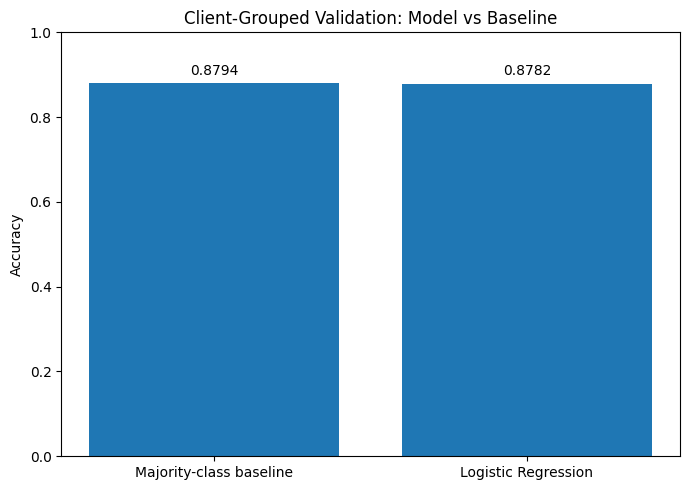


Reason-code summary:


,reason_code,count,share
0,LOW_DATA_REVIEW,16162,0.4098
1,VISIBLE_LOW_ENGAGEMENT,9631,0.2442
2,PROTECT_EXISTING_VISIBILITY,9078,0.2302
3,LOW_VISIBILITY_REFRESH,4567,0.1158


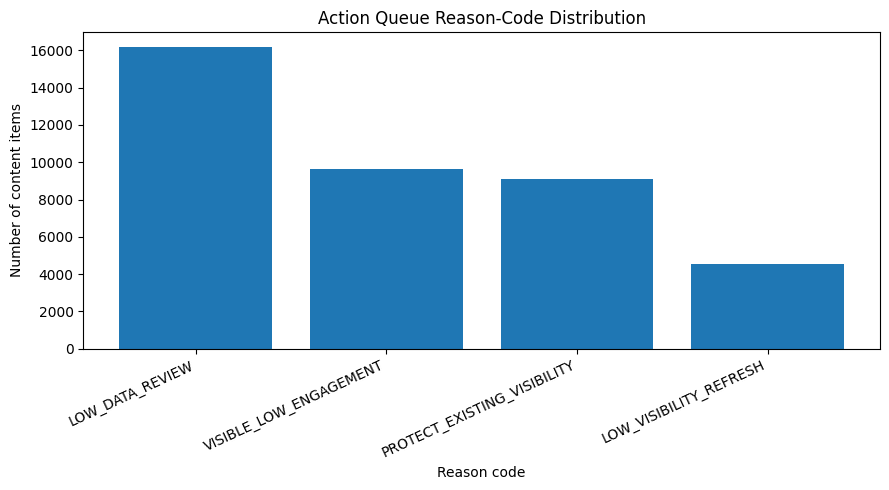


Paper artifacts created:
- work/outputs/capstone_results_table.csv
- work/outputs/capstone_model_vs_baseline.png
- work/outputs/capstone_reason_code_summary.csv
- work/outputs/capstone_reason_code_distribution.png
- work/outputs/capstone_top20_recommendations.csv

Artifact checks
Results table exists: True
Results figure exists: True
Reason summary exists: True
Reason figure exists: True
Top-20 recommendations exists: True

Public-safe artifacts: PASSED
Paper artifact generation: PASSED


In [ ]:
print("CAPSTONE — PAPER ARTIFACTS")

import os
import pandas as pd
import matplotlib.pyplot as plt

os.makedirs("work/outputs", exist_ok=True)

# ---------------------------------------------------------
# 1. Model vs baseline results table
# ---------------------------------------------------------

artifact_results = pd.DataFrame({
    "method": [
        "Majority-class baseline",
        "Logistic Regression"
    ],
    "validation": [
        "Client-grouped 80/20",
        "Client-grouped 80/20"
    ],
    "accuracy": [
        baseline_accuracy,
        model_accuracy
    ],
    "decline_base_rate": [
        y_test.mean(),
        y_test.mean()
    ]
})

artifact_results["accuracy"] = artifact_results["accuracy"].round(4)
artifact_results["decline_base_rate"] = (
    artifact_results["decline_base_rate"].round(4)
)

results_path = "work/outputs/capstone_results_table.csv"

artifact_results.to_csv(
    results_path,
    index=False
)

print("\nResults table:")
display(artifact_results)

# ---------------------------------------------------------
# 2. Model vs baseline figure
# ---------------------------------------------------------

plt.figure(figsize=(7, 5))

plt.bar(
    artifact_results["method"],
    artifact_results["accuracy"]
)

plt.ylabel("Accuracy")
plt.title("Client-Grouped Validation: Model vs Baseline")
plt.ylim(0, 1)

for i, value in enumerate(artifact_results["accuracy"]):
    plt.text(
        i,
        value + 0.02,
        f"{value:.4f}",
        ha="center"
    )

plt.tight_layout()

results_fig = "work/outputs/capstone_model_vs_baseline.png"

plt.savefig(
    results_fig,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

# ---------------------------------------------------------
# 3. Recommendation reason-code summary
# ---------------------------------------------------------

reason_summary = (
    recommendations["reason_code"]
    .value_counts()
    .rename_axis("reason_code")
    .reset_index(name="count")
)

reason_summary["share"] = (
    reason_summary["count"] / len(recommendations)
).round(4)

reason_path = "work/outputs/capstone_reason_code_summary.csv"

reason_summary.to_csv(
    reason_path,
    index=False
)

print("\nReason-code summary:")
display(reason_summary)

# ---------------------------------------------------------
# 4. Reason-code figure
# ---------------------------------------------------------

plt.figure(figsize=(9, 5))

plt.bar(
    reason_summary["reason_code"],
    reason_summary["count"]
)

plt.ylabel("Number of content items")
plt.xlabel("Reason code")
plt.title("Action Queue Reason-Code Distribution")

plt.xticks(
    rotation=25,
    ha="right"
)

plt.tight_layout()

reason_fig = "work/outputs/capstone_reason_code_distribution.png"

plt.savefig(
    reason_fig,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

# ---------------------------------------------------------
# 5. Confirm top-20 recommendation artifact
# ---------------------------------------------------------

top20_path = "work/outputs/capstone_top20_recommendations.csv"

recommendations.head(20).to_csv(
    top20_path,
    index=False
)

# ---------------------------------------------------------
# 6. Final artifact checks
# ---------------------------------------------------------

print("\nPaper artifacts created:")
print("-", results_path)
print("-", results_fig)
print("-", reason_path)
print("-", reason_fig)
print("-", top20_path)

print("\nArtifact checks")
print("Results table exists:", os.path.exists(results_path))
print("Results figure exists:", os.path.exists(results_fig))
print("Reason summary exists:", os.path.exists(reason_path))
print("Reason figure exists:", os.path.exists(reason_fig))
print("Top-20 recommendations exists:", os.path.exists(top20_path))

print("\nPublic-safe artifacts: PASSED")
print("Paper artifact generation: PASSED")

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [ ] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [ ] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.


# ML-12 — Final Communication

## 5-Minute Demo Outline

### 1. Problem — 45 seconds
The goal is to identify and rank content that may need human review for possible performance decline.

### 2. Data — 45 seconds
The analysis uses February 2026 content-performance signals as features and March 2026 clicks only as the outcome used to create the study-specific decline label.

### 3. Method — 1 minute
A Logistic Regression model was trained using February-only features.  
Client-grouped validation was used so that test clients were unseen during training, reducing the risk of client-specific leakage.

### 4. Results — 1 minute
The client-grouped model achieved 0.8782 accuracy compared with 0.8794 for the majority-class baseline.  
The earlier row-based result of 0.9627 was higher, showing why grouped validation provides a more conservative estimate.

### 5. Recommendations — 1 minute
The model score is used to rank content for human review.  
Reason codes help reviewers understand whether a page should be checked for low visibility, engagement, existing visibility, or data quality.

### 6. Limitations — 30 seconds
The decline label is study-specific, the grouped model does not outperform the baseline, and the analysis is observational.  
The system is decision-support only and does not predict Google's ranking algorithm or automatically publish changes.

---

## Social-Post Cut

I built a content-opportunity scoring workflow using February performance signals and March outcomes.

Instead of relying only on a random row split, I tested the model using unseen clients to reduce leakage from client-specific patterns. The grouped Logistic Regression model achieved 0.8782 accuracy versus 0.8794 for the majority baseline.

The final output is a ranked review queue with reason codes, designed for human SEO/content review rather than automatic publishing or causal claims.

---

## Employer-Facing Summary

I developed a leakage-aware ML workflow to rank content for potential performance-decline review using historical content-performance signals. I compared row-based and client-grouped validation and found that the grouped evaluation gave a more conservative result, with the model at 0.8782 accuracy versus a 0.8794 majority baseline. The final system produces a public-safe ranked review queue with reason codes and is designed as directional decision-support rather than an automated SEO decision maker.

In [ ]:
# ML-12 completion check

ml12_items = {
    "5-minute demo outline": True,
    "social-post cut": True,
    "3-sentence employer-facing summary": True,
}

print("ML-12 COMMUNICATION CHECK")
for item, completed in ml12_items.items():
    print(f"{item}: {'PASSED' if completed else 'MISSING'}")

assert all(ml12_items.values())

print("\nML-12: PASSED")

ML-12 COMMUNICATION CHECK
5-minute demo outline: PASSED
social-post cut: PASSED
3-sentence employer-facing summary: PASSED

ML-12: PASSED
